In [52]:
# Importing libraries
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import tensorflow as tf
import keras
from sklearn.preprocessing import StandardScaler
from scipy.special import softmax
import math
import random

In [53]:
final_df = pd.read_csv('dataset/final_df.csv')
final_df

,Date,Open,High,Low,Close,Adj Close,negative_top1,neutral_top1,positive_top1,negative_top2,...,positive_top22,negative_top23,neutral_top23,positive_top23,negative_top24,neutral_top24,positive_top24,negative_top25,neutral_top25,positive_top25
0,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,11734.320312,0.552167,0.437650,0.010183,0.285199,...,0.007727,0.772411,0.217763,0.009826,0.917584,0.079171,0.003245,0.638448,0.349005,0.012547
1,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,11782.349609,0.744413,0.247436,0.008151,0.222044,...,0.028260,0.186386,0.782731,0.030883,0.104860,0.315958,0.579182,0.588637,0.393123,0.018240
2,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,11642.469727,0.591630,0.336137,0.072233,0.186763,...,0.006967,0.696832,0.295765,0.007403,0.081891,0.886369,0.031740,0.276685,0.685307,0.038007
3,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,11532.959961,0.265182,0.719142,0.015676,0.865281,...,0.008805,0.649133,0.345063,0.005804,0.461480,0.519256,0.019263,0.387972,0.591107,0.020921
4,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,11615.929688,0.228814,0.665338,0.105847,0.426495,...,0.002120,0.393785,0.562838,0.043377,0.805248,0.191262,0.003490,0.187739,0.786013,0.026248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,17140.240234,0.709384,0.281499,0.009118,0.173237,...,0.029173,0.599290,0.386043,0.014666,0.154987,0.796752,0.048262,0.073729,0.897968,0.028303
1985,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,17409.720703,0.246073,0.662917,0.091010,0.863117,...,0.573029,0.077206,0.883706,0.039088,0.412548,0.575525,0.011927,0.846545,0.148250,0.005205
1986,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,17694.679688,0.539544,0.444304,0.016152,0.672122,...,0.006216,0.754316,0.237468,0.008215,0.043520,0.842496,0.113983,0.336117,0.604508,0.059375
1987,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,17929.990234,0.020837,0.849318,0.129845,0.842417,...,0.048489,0.634697,0.343935,0.021369,0.697932,0.292597,0.009471,0.373225,0.616739,0.010035


## Setting the Base Model to Beat

We will compare every model created to the naive model. The naive model is where the price on day 𝑖+1 is equal to the price on day 𝑖.

To evaluate the models, we will use a metric called the Mean Average Scaled Error (MASE). It is calculated by [Current Model MAE]/[Naive Model MAE].

Since we have 1989 different datapoints, we will train on the first ~1800 datapoints and try to predict the last 150 points.

To give an idea as to what the Naive Model should look like, here is the plotted graph:



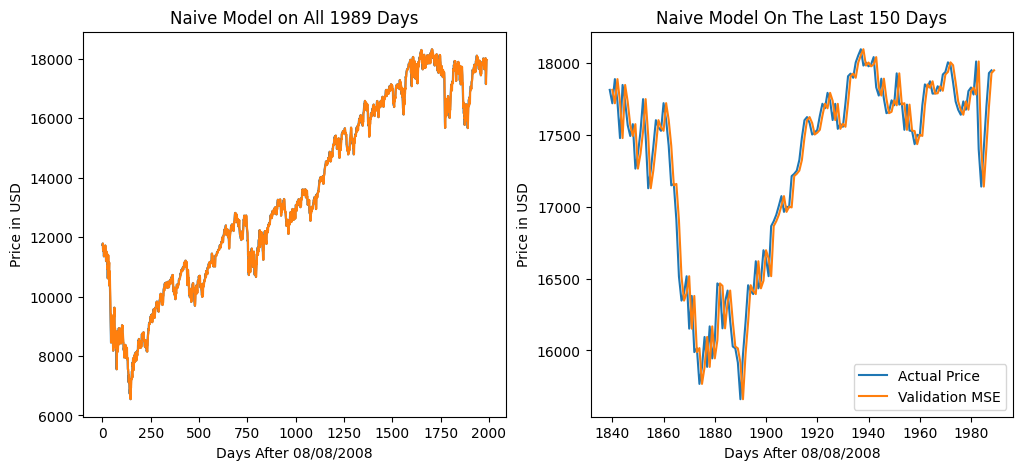

In [54]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(final_df['Adj Close'], label="Actual Price")
plt.plot(final_df['Adj Close'].index+1, final_df['Adj Close'], label="Naive Model")
plt.title('Naive Model on All 1989 Days')
plt.xlabel('Days After 08/08/2008')
plt.ylabel('Price in USD')
plt.subplot(1, 2, 2)
plt.plot(final_df['Adj Close'][-150:], label="Actual Price")
plt.plot(np.asarray(final_df['Adj Close'].index[-150:])+1, final_df['Adj Close'].iloc[-150:], label="Validation MSE")
plt.title('Naive Model On The Last 150 Days')
plt.xlabel('Days After 08/08/2008')
plt.ylabel('Price in USD')
plt.legend()

In [55]:
model_history, model_name=[], [] #This will act as the placeholder for all model name and its results

# Averaging out the sentiment

Based on the exploratory data analysis done earlier, averaging out the sentiment may be more impactful as opposed to using the individual values.

In [56]:
prefixes = ["negative", "neutral", "positive"]

for prefix in prefixes:
    columns_to_average = [f"{prefix}_top{i}" for i in range(1, 26)]

    final_df[f"{prefix}_average"] = final_df[columns_to_average].mean(axis=1)

In [57]:
reg_final_df = final_df.loc[:, ["Open", "High", "Low", "Close", "Adj Close", "positive_average", "negative_average", "neutral_average"]]

# Creating Utility Functions
To decrease the repetition of code, we define a few utility functions that can help with the whole process.

* `get_history` returns a pandas DataFrame that shows all the model errors and name for final evaluation.
* `preprocess` returns the scaled train and validation datasets for both the independent and dependent variables, X and y respectively, as well as the standard scaler itself.
*   `plot_history` plots the Loss and MSE graphs of each model to gain a visual sense on how the model is learning through each epoch (i.e. any signs of overfitting, etc.)
*   `get_MAE` returns the mean absolute error in general for 2 array of numbers, but in this context, we'll use it to get the MAE of the current model's predictions with respect to the actual price.
*  `get_MASE` returns the mean absolute scaled error of the current model. Calculated by [Current Model MAE]/[Naive Model MAE].
*  `model_predict` predicts the price of the last `steps` steps of the validation set `X_valid` using the model `model`.
* `reset_seed` resets the randomization seed for reproducability.


In [58]:
def get_history():
  return pd.DataFrame(model_history, model_name)

def reset_seed(seed=48):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)    

In [59]:
def preprocess(df, n_future, n_past):
  scaler = StandardScaler()
  scaler = scaler.fit(df)
  scaled_df = np.asarray(scaler.transform(df))

  X_train, y_train = [], []

  for i in range(n_past, len(scaled_df) - n_future + 1):
    X_train.append(scaled_df[i-n_past: i, :])
    y_train.append(scaled_df[i+n_future-1:i+n_future, 4])

  X, y = np.array(X_train), np.array(y_train)

  X_train = X[:1800]
  y_train = y[:1800]
  X_valid = X[1800:]
  y_valid = y[1800:]

  return X_train, y_train, X_valid, y_valid, scaler

def plot_history(history):
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history["loss"], label="Training Loss")
  plt.plot(history.history["val_loss"], label="Validation Loss")
  plt.title('Training Loss vs Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.subplot(1, 2, 2)
  plt.plot(history.history["mean_squared_error"], label="Training MSE")
  plt.plot(history.history["val_mean_squared_error"], label="Validation MSE")
  plt.title('Training MSE vs Validation MSE')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()

def get_MAE(y_true, y_pred):
  return np.mean(np.abs(y_true - y_pred))

def get_MASE(y_true, y_pred):
  naive_forecast = y_true[:-1]
  mae = get_MAE(y_true, y_pred)
  naive_mae = get_MAE(y_true[1:], naive_forecast)
  return mae/naive_mae

def model_predict(steps, X_valid, model, scaler, val_mse, name):
  n_future = steps
  forecast = model.predict(X_valid[-n_future:], verbose=0)
  forecast_copies = np.repeat(forecast, X_valid.shape[2], axis=-1)
  y_pred_future = scaler.inverse_transform(forecast_copies)[:, 4]

  val_mse_copies = np.repeat(val_mse, X_valid.shape[2], axis=-1).reshape((1, X_valid.shape[2]))
  real_val_mse = scaler.inverse_transform(val_mse_copies)[:, 4]

  plt.plot(y_pred_future, label="Predicted")
  plt.plot(list(final_df.iloc[-n_future:, 4]), label="Actual")
  plt.legend()

  mase = get_MASE(np.array(final_df.iloc[-n_future:, 4]), y_pred_future)
  mse = real_val_mse[0]
  print(f"Mean Absolute Scaled Error: {mase}")
  print(f"Model Mean Squared Error: {mse}")

  error={
      "MASE":float(mase),
      "MSE":float(mse),
      "RMSE":float(np.sqrt(mse))
  }

  model_history.append(error)
  model_name.append(name)

In [60]:
X_train, y_train, X_valid, y_valid, scaler = preprocess(reg_final_df, 1, 9)

# LSTMs

## Base LSTM


In [61]:
reset_seed() # for reproducibility
model_1 = keras.Sequential([
    keras.layers.LSTM(32, input_shape=[X_train.shape[1], X_train.shape[2]], return_sequences=True),
    keras.layers.LSTM(16, return_sequences=False),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

model_1.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.Adam(),
              metrics=[keras.losses.MeanSquaredError()])

history_1 = model_1.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=10, batch_size=16, verbose=1)

/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1045 - mean_squared_error: 0.1041 - val_loss: 0.0111 - val_mean_squared_error: 0.0111
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0099 - val_mean_squared_error: 0.0097
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0093 - val_mean_squared_error: 0.0091
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0092 - val_mean_squared_error: 0.0090
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063 - mean_squared_error: 0.0063 - val_loss: 0.0090 - val_mean_squared_error: 0.0088
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0089 - val_mean_squared_error: 0.0086
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.00

We can visualize what the base architecture looks like using `tf.keras.utils.plot_model()`

In [62]:
keras.utils.plot_model(model_1, to_file="model_1.png", show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Plotting these history graphs can tell us how our model is learning. In the case of overfitting when more epochs are introduced, overfitting may be a very likely problem. But since we are still testing the initial model, it is not apparent.

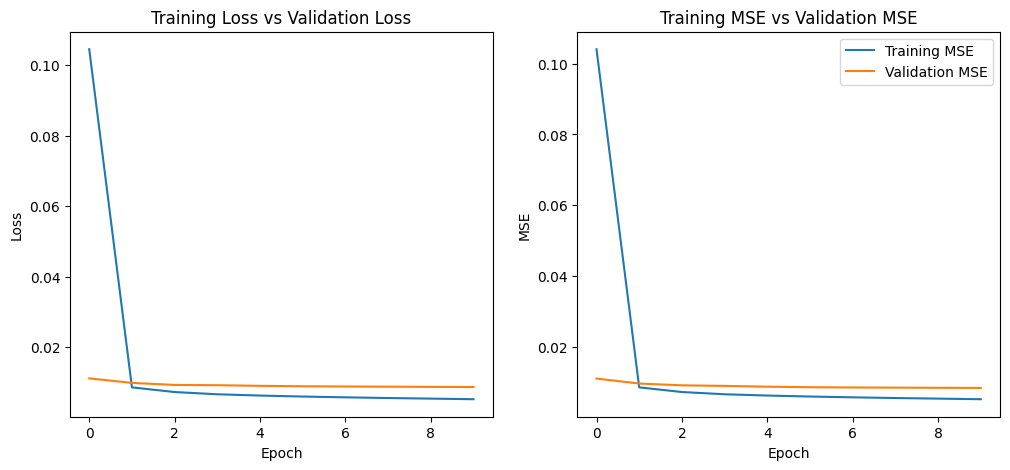

In [63]:
plot_history(history_1)

Mean Absolute Scaled Error: 1.7704222774609364
Model Mean Squared Error: 13489.48914778022


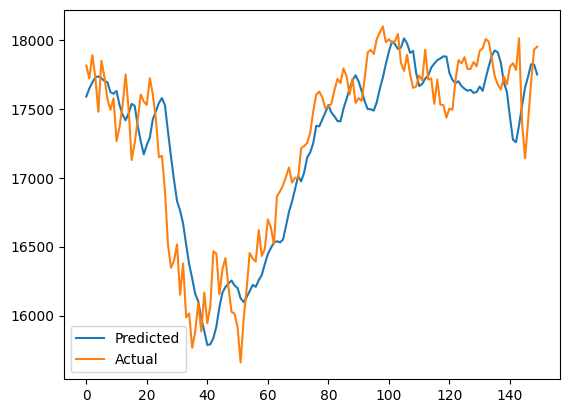

In [64]:
model_predict(150, X_valid, model_1, scaler, min(history_1.history["val_mean_squared_error"]), "Base LSTM")

An MASE of 1.564426 means our MAE is 1.564426 times larger than the naive model's MAE. We still have quite a long way to go.


## Deep LSTM + Fine Tuning


In [65]:
reset_seed() # for reproducibility
model_2 = keras.Sequential([
    keras.layers.LSTM(32, input_shape=[X_train.shape[1], X_train.shape[2]], return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(32, return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(16, return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(16, return_sequences=False, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(8, activation='relu', kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(1, activation='linear')
])

batch_size=16
n_epochs=200
n_steps=n_epochs * math.ceil(len(X_train)/batch_size)
slr = keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=0.02, decay_steps=n_steps, decay_rate=0.1)

model_2.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.Adam(learning_rate=slr),
              metrics=[keras.losses.MeanSquaredError()])

history_2 = model_2.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=n_epochs, batch_size=batch_size, verbose=1,
                        callbacks=[keras.callbacks.EarlyStopping(monitor="val_mean_squared_error", patience=15, restore_best_weights=True)])


Epoch 1/200


/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3831 - mean_squared_error: 0.0670 - val_loss: 0.1006 - val_mean_squared_error: 0.0296
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0733 - mean_squared_error: 0.0287 - val_loss: 0.0434 - val_mean_squared_error: 0.0152
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0509 - mean_squared_error: 0.0268 - val_loss: 0.0382 - val_mean_squared_error: 0.0190
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0495 - mean_squared_error: 0.0295 - val_loss: 0.0304 - val_mean_squared_error: 0.0123
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0331 - mean_squared_error: 0.0171 - val_loss: 0.0260 - val_mean_squared_error: 0.0120
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0413 - mean_squared_error: 0.0257 - val_loss: 0.0253 - val_mean_squared_error: 0.0104
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0292 - mean_squared_error: 0.0157 - val_loss: 0.0224 - 

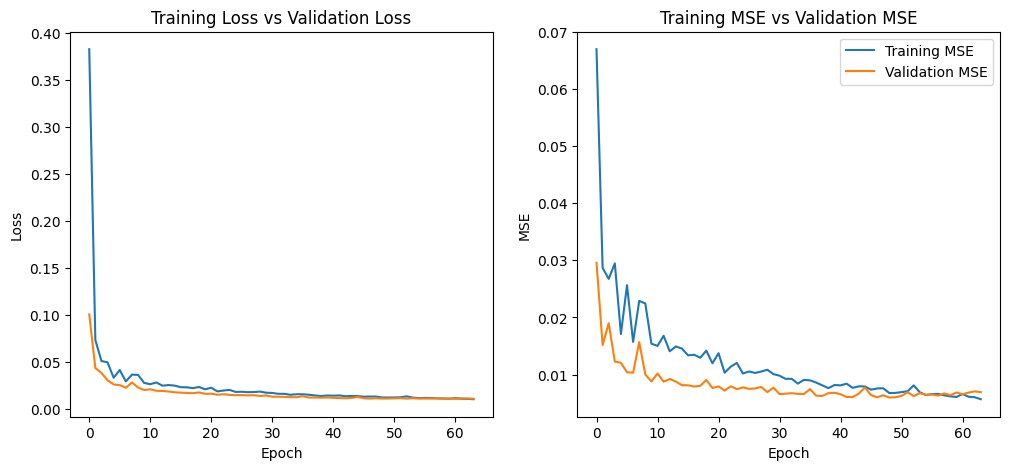

In [66]:
plot_history(history_2)

When introducing deeper neural network models, overfitting becomes even more likely, therefore we introduce l2 regularizers to add penalty in training to reduce overfitting of data.

Mean Absolute Scaled Error: 1.3983168623709796
Model Mean Squared Error: 13481.81958684884


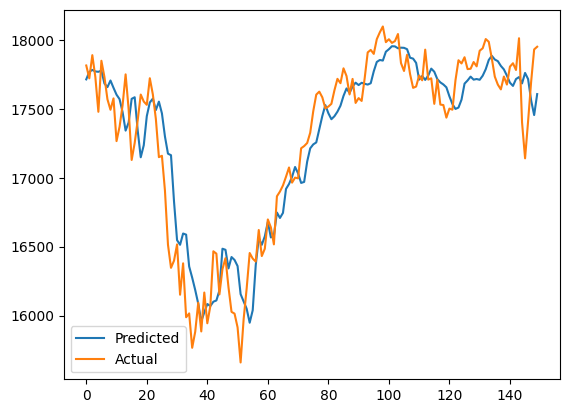

In [67]:
model_predict(150, X_valid, model_2, scaler, min(history_2.history["val_mean_squared_error"]), "Deep(er) LSTM with Fine Tuning")

## Fine Tuned Base LSTM


In [68]:
reset_seed() # for reproducibility
model_3 = keras.Sequential([
    keras.layers.LSTM(32, input_shape=[X_train.shape[1], X_train.shape[2]], return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(16, return_sequences=False, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(8, activation='relu', kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(1, activation='linear')
])

batch_size=16
n_epochs=200

model_3.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.Adam(learning_rate=0.03),
              metrics=[keras.losses.MeanSquaredError()])

history_3 = model_3.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=n_epochs, batch_size=batch_size, verbose=1,
                        callbacks=[keras.callbacks.EarlyStopping(monitor="val_mean_squared_error", patience=15, restore_best_weights=True),
                                   keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=3, min_lr=0.000001)])


Epoch 1/200


/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2516 - mean_squared_error: 0.0482 - val_loss: 0.0591 - val_mean_squared_error: 0.0074 - learning_rate: 0.0300
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0422 - mean_squared_error: 0.0132 - val_loss: 0.0263 - val_mean_squared_error: 0.0088 - learning_rate: 0.0300
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0234 - mean_squared_error: 0.0105 - val_loss: 0.0215 - val_mean_squared_error: 0.0105 - learning_rate: 0.0300
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0224 - mean_squared_error: 0.0125 - val_loss: 0.0155 - val_mean_squared_error: 0.0068 - learning_rate: 0.0300
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0200 - mean_squared_error: 0.0118 - val_loss: 0.0156 - val_mean_squared_error: 0.0080 - learning_rate: 0.0300
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0168 - mean_squared_error: 0.0097 - val_loss: 0.0133 - val_mean_squared_error: 0.006

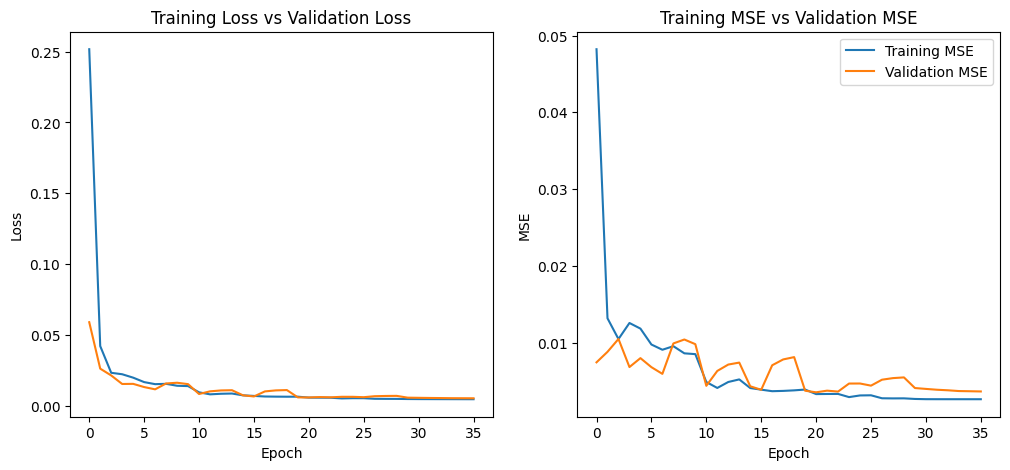

In [69]:
plot_history(history_3)

Mean Absolute Scaled Error: 1.1213684271300193
Model Mean Squared Error: 13474.071392213142


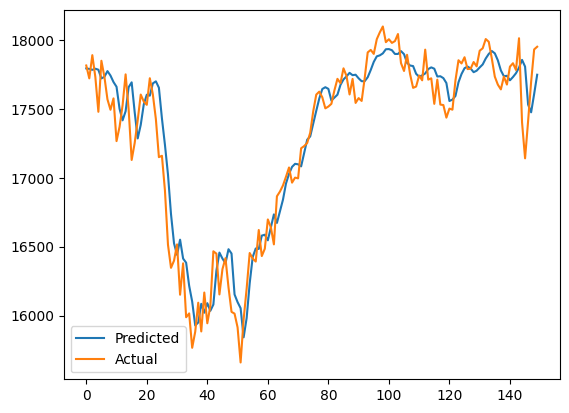

In [70]:
model_predict(150, X_valid, model_3, scaler, min(history_3.history["val_mean_squared_error"]), "Fine Tuned Base LSTM")

## Experimenting on `n_past` values

From the start, we took `n_past` to be an arbitrary value 9 where 9 feels like a good enough window of days to represent the current state of the market to predict the following day. In this section, we will visualise values of `n_past` form 1 to 20 to find out the best value for the given model.

In [71]:
w_mse, w_mase = [], []
for i in tqdm(range(1, 21)):

  X_train, y_train, X_valid, y_valid, scaler = preprocess(reg_final_df, 1, i)
  
  # Retrain model 3 for different window size
  reset_seed() # for reproducibility
  model_3 = keras.Sequential([
    keras.layers.LSTM(32, input_shape=[X_train.shape[1], X_train.shape[2]], return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(16, return_sequences=False, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(8, activation='relu', kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(1, activation='linear')
  ])
  batch_size=16
  n_epochs=200

  model_3.compile(loss=keras.losses.MeanSquaredError(),
                optimizer=keras.optimizers.Adam(learning_rate=0.03),
                metrics=[keras.losses.MeanSquaredError()])
  
  history_i = model_3.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=n_epochs, batch_size=batch_size, verbose=0,
                        callbacks=[keras.callbacks.EarlyStopping(monitor="val_mean_squared_error", patience=15, restore_best_weights=True),
                                   keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=3, min_lr=0.000001)])
  
  forecast = model_3.predict(X_valid[-150:], verbose=0)
  forecast_copies = np.repeat(forecast, X_valid.shape[2], axis=-1)
  y_pred_future = scaler.inverse_transform(forecast_copies)[:, 4]

  val_mse_copies = np.repeat(history_i.history["val_mean_squared_error"][-1], X_valid.shape[2], axis=-1).reshape((1, 8))
  real_val_mse = scaler.inverse_transform(val_mse_copies)[:, 4]
  cur_mase = get_MASE(np.array(final_df.iloc[-150:, 4]), y_pred_future)
  w_mase.append(cur_mase)
  w_mse.append(real_val_mse[0])

  0%|          | 0/20 [00:00<?, ?it/s]/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
  5%|▌         | 1/20 [00:05<01:52,  5.90s/it]/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
 10%|█         | 2/20 [00:11<01:45,  5.86s/it]/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. 

/var/folders/wg/d031v9s174970_gv9b_sxrlm0000gn/T/ipykernel_19886/805240280.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


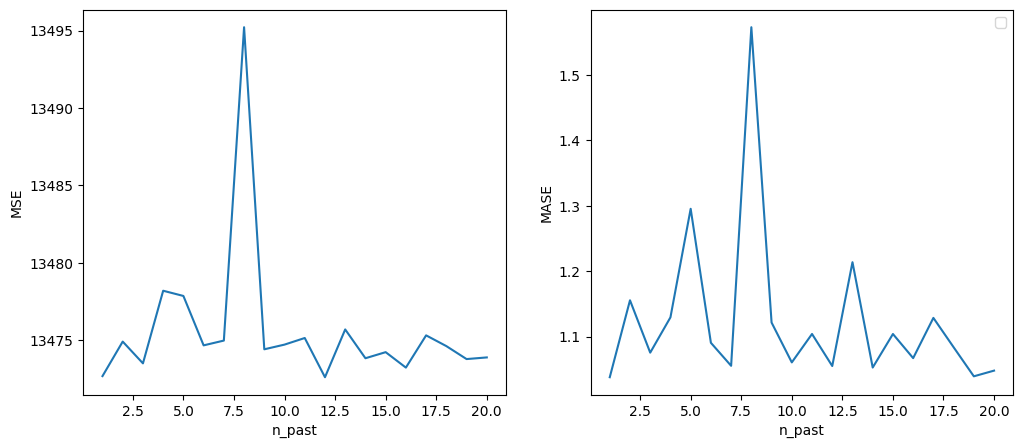

In [72]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([i for i in range(1, 21)], w_mse)
plt.xlabel('n_past')
plt.ylabel('MSE')
plt.subplot(1, 2, 2)
plt.plot([i for i in range(1, 21)], w_mase)
plt.xlabel('n_past')
plt.ylabel('MASE')
plt.legend()

From the above, we see that `n_past` of 3 is able to obtain the lowest MASE but has a very high MSE. `n_past` of 12 produces the lowest MSE but an MASE that is increasing to above 1. We can conclude that to minimise both, we can take `n_past` to be 9, making `n_past` unchanged.

# Feature Engineering

When we have fine tuned the model as best as we can and its not showing any signs of converging to a more accurate model, we can start to introduce feature engineered features from the EDA to help with our prediction.

In [73]:
short_window = 12
long_window = 26
signal_window = 9

reg_final_df['ShortEMA'] = reg_final_df['Adj Close'].ewm(span=short_window, min_periods=1, adjust=False).mean()
reg_final_df['LongEMA'] = reg_final_df['Adj Close'].ewm(span=long_window, min_periods=1, adjust=False).mean()
reg_final_df['MACD'] = reg_final_df['ShortEMA'] - reg_final_df['LongEMA']
reg_final_df['Signal Line'] = reg_final_df['MACD'].ewm(span=signal_window, min_periods=1, adjust=False).mean()

In [74]:
window_length = 14

delta = reg_final_df['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=window_length, min_periods=1).mean()
avg_loss = loss.rolling(window=window_length, min_periods=1).mean()
rs = avg_gain / avg_loss
reg_final_df['RSI'] = 100 - (100 / (1 + rs))

In [75]:
window_length = 20

reg_final_df['MA'] = reg_final_df['Adj Close'].rolling(window=window_length, min_periods=1).mean()

In [76]:
reg_final_df = reg_final_df.iloc[2:, :] #Cuts off the NaN values
reg_final_df

,Open,High,Low,Close,Adj Close,positive_average,negative_average,neutral_average,ShortEMA,LongEMA,MACD,Signal Line,RSI,MA
2,11781.700195,11782.349609,11601.519531,11642.469727,11642.469727,0.050652,0.419876,0.529472,11726.441787,11730.810755,-4.368968,-0.260770,25.559846,11719.713216
3,11632.809570,11633.780273,11453.339844,11532.959961,11532.959961,0.069281,0.372418,0.558301,11696.675352,11716.155141,-19.479789,-4.104574,16.148701,11673.024902
4,11532.070312,11718.280273,11450.889648,11615.929688,11615.929688,0.067112,0.456842,0.476046,11684.252943,11708.731033,-24.478091,-8.179277,34.438203,11661.605859
5,11611.209961,11709.889648,11599.730469,11659.900391,11659.900391,0.030144,0.518181,0.451674,11680.506396,11705.113949,-24.607553,-11.464932,41.231498,11661.321615
6,11659.650391,11690.429688,11434.120117,11479.389648,11479.389648,0.040285,0.395522,0.564193,11649.565358,11688.393630,-38.828272,-16.937600,28.926826,11635.331334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,17355.210938,17355.210938,17063.080078,17140.240234,17140.240234,0.086128,0.379124,0.534749,17657.372886,17714.658350,-57.285464,-1.439935,28.854991,17767.995019
1985,17190.509766,17409.720703,17190.509766,17409.720703,17409.720703,0.100497,0.364998,0.534505,17619.272550,17692.070376,-72.797826,-15.711513,35.756096,17749.121094
1986,17456.019531,17704.509766,17456.019531,17694.679688,17694.679688,0.128377,0.515269,0.356353,17630.873648,17692.263658,-61.390010,-24.847213,43.831722,17744.371582
1987,17712.759766,17930.609375,17711.800781,17929.990234,17929.990234,0.077534,0.490189,0.432277,17676.891584,17709.873034,-32.981450,-26.474060,51.308537,17748.943066


In [77]:
X_train, y_train, X_valid, y_valid, scaler = preprocess(reg_final_df, 1, 9)

## Fine Tuned Base LSTM + extra features

In [78]:
reset_seed() # for reproducibility
model_4 = keras.Sequential([
    keras.layers.LSTM(32, input_shape=[X_train.shape[1], X_train.shape[2]], return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(16, return_sequences=False, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(8, activation='relu', kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(1, activation='linear')
])

batch_size=16
n_epochs=100

model_4.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.Adam(learning_rate=0.03),
              metrics=[keras.losses.MeanSquaredError()])

history_4 = model_4.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=n_epochs, batch_size=batch_size, verbose=1,
                        callbacks=[keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=3, min_lr=0.000001),
                                   keras.callbacks.EarlyStopping(monitor="val_mean_squared_error", patience=35, restore_best_weights=True)])

Epoch 1/100


/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2560 - mean_squared_error: 0.0592 - val_loss: 0.0595 - val_mean_squared_error: 0.0138 - learning_rate: 0.0300
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0456 - mean_squared_error: 0.0169 - val_loss: 0.0302 - val_mean_squared_error: 0.0180 - learning_rate: 0.0300
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0278 - mean_squared_error: 0.0142 - val_loss: 0.0176 - val_mean_squared_error: 0.0083 - learning_rate: 0.0300
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0249 - mean_squared_error: 0.0142 - val_loss: 0.0191 - val_mean_squared_error: 0.0088 - learning_rate: 0.0300
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0201 - mean_squared_error: 0.0116 - val_loss: 0.0263 - val_mean_squared_error: 0.0168 - learning_rate: 0.0300
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0180 - mean_squared_error: 0.0103 - val_loss: 0.0176 - val_mean_squared_error: 0.009

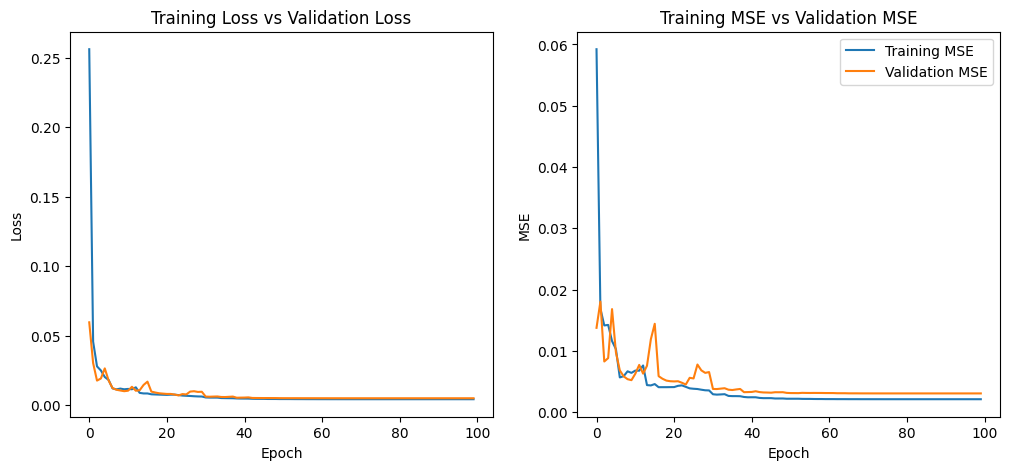

In [79]:
plot_history(history_4)

Mean Absolute Scaled Error: 1.008022581865115
Model Mean Squared Error: 13474.394368800662


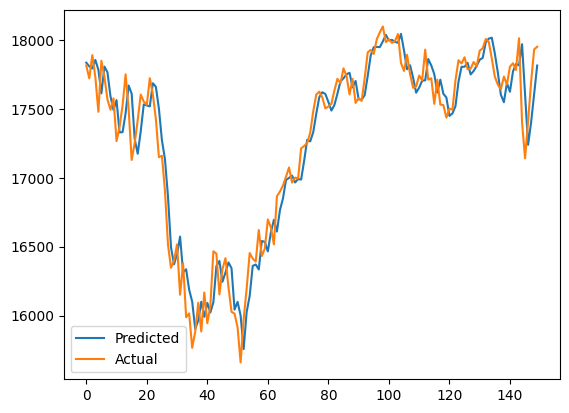

In [80]:
model_predict(150, X_valid, model_4, scaler, min(history_4.history["val_mean_squared_error"]), "Fine Tuned LSTM + Extra Features")

## Fine Tuned Base LSTM + Extra Features++

In [81]:
def calculate_atr(df, window=14):
    high_low = df['High'] - df['Low']
    high_close = abs(df['High'] - df['Close'].shift(1))
    low_close = abs(df['Low'] - df['Close'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    atr = true_range.rolling(window=window).mean()
    df['ATR'] = atr
    return df
reg_final_df = calculate_atr(reg_final_df)

def calculate_stochastic_oscillator(df, period=14):
    low_min = df['Low'].rolling(window=period).min()
    high_max = df['High'].rolling(window=period).max()
    df['%K'] = 100 * ((df['Close'] - low_min) / (high_max - low_min))
    df['%D'] = df['%K'].rolling(window=3).mean()
    return df
reg_final_df = calculate_stochastic_oscillator(reg_final_df)

def calculate_bollinger_bands(df, window=20, num_std_dev=2):
    rolling_mean = df['Close'].rolling(window=window).mean()
    rolling_std = df['Close'].rolling(window=window).std()
    df['Upper Band'] = rolling_mean + (num_std_dev * rolling_std)
    df['Lower Band'] = rolling_mean - (num_std_dev * rolling_std)
    return df
reg_final_df = calculate_bollinger_bands(reg_final_df)

In [82]:
reg_final_df = reg_final_df.iloc[21:, :] #Cuts the NaN Values
reg_final_df

,Open,High,Low,Close,Adj Close,positive_average,negative_average,neutral_average,ShortEMA,LongEMA,MACD,Signal Line,RSI,MA,ATR,%K,%D,Upper Band,Lower Band
23,11264.440430,11445.679688,11098.669922,11433.709961,11433.709961,0.054565,0.407619,0.537817,11402.937559,11485.274593,-82.337034,-75.337062,50.082046,11452.166455,239.685687,52.618591,36.323691,11749.634043,11154.698867
24,11429.320312,11459.929688,11280.400391,11421.990234,11421.990234,0.034756,0.532605,0.432639,11405.868740,11480.586863,-74.718123,-75.213274,44.707560,11442.469483,237.842076,51.060781,44.797908,11729.935607,11155.003358
25,11416.370117,11416.450195,10917.509766,10917.509766,10917.509766,0.042992,0.488758,0.468250,11330.736590,11438.877448,-108.140858,-81.798791,39.392608,11405.349951,254.917132,0.000000,34.559791,11758.761589,11051.938313
26,10905.620117,11093.219727,10742.700195,11059.019531,11059.019531,0.078224,0.485635,0.436141,11288.933966,11410.739825,-121.805859,-89.800205,42.388305,11384.331445,273.109236,30.198423,27.086401,11767.916011,11000.746880
27,11056.580078,11057.309570,10595.900391,10609.660156,10609.660156,0.036507,0.501637,0.461856,11184.430303,11351.400590,-166.970287,-105.234221,33.367849,11347.386963,293.854144,1.152149,10.450191,11864.553067,10830.220859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,17355.210938,17355.210938,17063.080078,17140.240234,17140.240234,0.086128,0.379124,0.534749,17657.372886,17714.658350,-57.285464,-1.439935,28.854991,17767.995019,208.303711,8.097234,37.974834,18178.867296,17357.122743
1985,17190.509766,17409.720703,17190.509766,17409.720703,17409.720703,0.100497,0.364998,0.534505,17619.272550,17692.070376,-72.797826,-15.711513,35.756096,17749.121094,221.545898,36.565843,17.131785,18189.872442,17308.369746
1986,17456.019531,17704.509766,17456.019531,17694.679688,17694.679688,0.128377,0.515269,0.356353,17630.873648,17692.263658,-61.390010,-24.847213,43.831722,17744.371582,236.220843,66.625118,37.096065,18185.330302,17303.412862
1987,17712.759766,17930.609375,17711.800781,17929.990234,17929.990234,0.077534,0.490189,0.432277,17676.891584,17709.873034,-32.981450,-26.474060,51.308537,17748.943066,240.726563,91.447161,64.879374,18195.868604,17302.017529


In [83]:
X_train, y_train, X_valid, y_valid, scaler = preprocess(reg_final_df, 1, 9)

In [84]:
reset_seed() # for reproducibility
model_5= keras.Sequential([
    keras.layers.LSTM(32, input_shape=[X_train.shape[1], X_train.shape[2]], return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(16, return_sequences=False, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(8, activation='relu', kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(1, activation='linear')
])

batch_size=16
n_epochs=200

model_5.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.Nadam(learning_rate=0.037),
              metrics=[keras.losses.MeanSquaredError()])

history_5= model_5.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=n_epochs, batch_size=batch_size, verbose=2,
                        callbacks=[keras.callbacks.ReduceLROnPlateau(monitor='val_mean_squared_error', factor=0.4, patience=4, min_lr=1e-11),
                                   keras.callbacks.EarlyStopping(monitor="val_mean_squared_error", patience=35, restore_best_weights=True)])

Epoch 1/200


/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 - 2s - 19ms/step - loss: 0.2141 - mean_squared_error: 0.0569 - val_loss: 0.0416 - val_mean_squared_error: 0.0110 - learning_rate: 0.0370
Epoch 2/200
113/113 - 0s - 2ms/step - loss: 0.0348 - mean_squared_error: 0.0148 - val_loss: 0.0211 - val_mean_squared_error: 0.0066 - learning_rate: 0.0370
Epoch 3/200
113/113 - 0s - 2ms/step - loss: 0.0254 - mean_squared_error: 0.0136 - val_loss: 0.0151 - val_mean_squared_error: 0.0054 - learning_rate: 0.0370
Epoch 4/200
113/113 - 0s - 2ms/step - loss: 0.0209 - mean_squared_error: 0.0120 - val_loss: 0.0184 - val_mean_squared_error: 0.0078 - learning_rate: 0.0370
Epoch 5/200
113/113 - 0s - 2ms/step - loss: 0.0171 - mean_squared_error: 0.0093 - val_loss: 0.0156 - val_mean_squared_error: 0.0082 - learning_rate: 0.0370
Epoch 6/200
113/113 - 0s - 2ms/step - loss: 0.0164 - mean_squared_error: 0.0095 - val_loss: 0.0135 - val_mean_squared_error: 0.0069 - learning_rate: 0.0370
Epoch 7/200
113/113 - 0s - 2ms/step - loss: 0.0182 - mean_squared_error: 0.

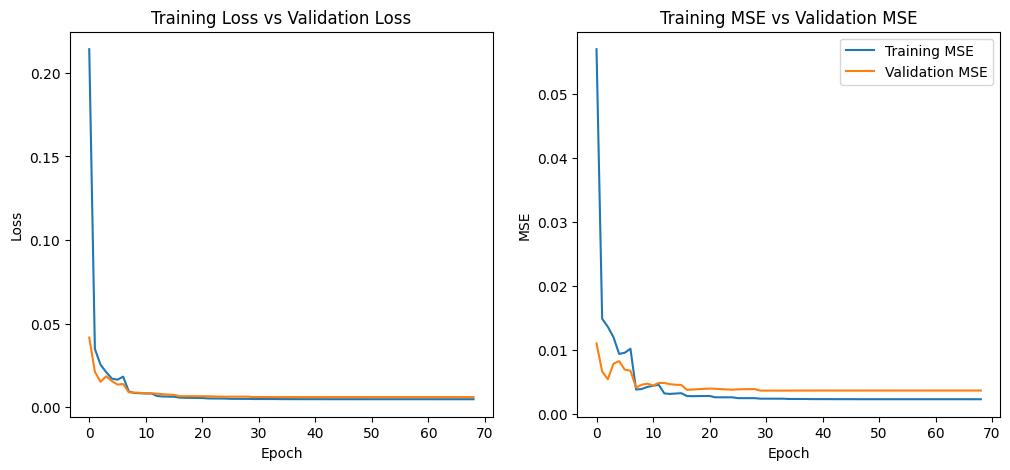

In [85]:
plot_history(history_5)

Mean Absolute Scaled Error: 1.107910266924101
Model Mean Squared Error: 13497.449798932365


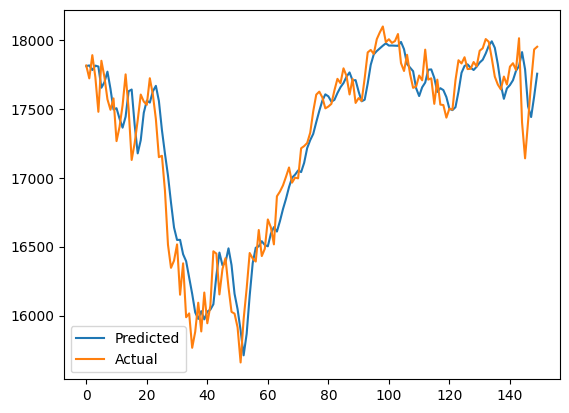

In [86]:
model_predict(150, X_valid, model_5, scaler, min(history_5.history["val_mean_squared_error"]), "Fine Tuned LSTM + More Features")

We have successfully beaten the baseline naive model since the MASE < 1, meaning our `model_5` MAE is ~0.989949 times smaller than the naive model's MAE.

#Predicting Without Sentiments

To further confirm our doubts if sentiments truly play a role in increasing the accuracy of prediction, we try to run our analysis without the sentiment features.

In [87]:
reg_final_df = reg_final_df.drop(["positive_average", "negative_average", "neutral_average"], axis=1)
reg_final_df

,Open,High,Low,Close,Adj Close,ShortEMA,LongEMA,MACD,Signal Line,RSI,MA,ATR,%K,%D,Upper Band,Lower Band
23,11264.440430,11445.679688,11098.669922,11433.709961,11433.709961,11402.937559,11485.274593,-82.337034,-75.337062,50.082046,11452.166455,239.685687,52.618591,36.323691,11749.634043,11154.698867
24,11429.320312,11459.929688,11280.400391,11421.990234,11421.990234,11405.868740,11480.586863,-74.718123,-75.213274,44.707560,11442.469483,237.842076,51.060781,44.797908,11729.935607,11155.003358
25,11416.370117,11416.450195,10917.509766,10917.509766,10917.509766,11330.736590,11438.877448,-108.140858,-81.798791,39.392608,11405.349951,254.917132,0.000000,34.559791,11758.761589,11051.938313
26,10905.620117,11093.219727,10742.700195,11059.019531,11059.019531,11288.933966,11410.739825,-121.805859,-89.800205,42.388305,11384.331445,273.109236,30.198423,27.086401,11767.916011,11000.746880
27,11056.580078,11057.309570,10595.900391,10609.660156,10609.660156,11184.430303,11351.400590,-166.970287,-105.234221,33.367849,11347.386963,293.854144,1.152149,10.450191,11864.553067,10830.220859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,17355.210938,17355.210938,17063.080078,17140.240234,17140.240234,17657.372886,17714.658350,-57.285464,-1.439935,28.854991,17767.995019,208.303711,8.097234,37.974834,18178.867296,17357.122743
1985,17190.509766,17409.720703,17190.509766,17409.720703,17409.720703,17619.272550,17692.070376,-72.797826,-15.711513,35.756096,17749.121094,221.545898,36.565843,17.131785,18189.872442,17308.369746
1986,17456.019531,17704.509766,17456.019531,17694.679688,17694.679688,17630.873648,17692.263658,-61.390010,-24.847213,43.831722,17744.371582,236.220843,66.625118,37.096065,18185.330302,17303.412862
1987,17712.759766,17930.609375,17711.800781,17929.990234,17929.990234,17676.891584,17709.873034,-32.981450,-26.474060,51.308537,17748.943066,240.726563,91.447161,64.879374,18195.868604,17302.017529


In [88]:
X_train, y_train, X_valid, y_valid, scaler = preprocess(reg_final_df, 1, 9)

In [89]:
reset_seed() # for reproducibility
model_6= keras.Sequential([
    keras.layers.LSTM(32, input_shape=[X_train.shape[1], X_train.shape[2]], return_sequences=True, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.LSTM(16, return_sequences=False, kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(8, activation='relu', kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.0013)),
    keras.layers.Dense(1, activation='linear')
])

batch_size=16
n_epochs=200

model_6.compile(loss=keras.losses.MeanSquaredError(),
              optimizer=keras.optimizers.Adam(learning_rate=0.03),
              metrics=[keras.losses.MeanSquaredError()])

history_6 = model_6.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=n_epochs, batch_size=batch_size, verbose=1,
                        callbacks=[keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3, min_lr=0.000001),
                                   keras.callbacks.EarlyStopping(monitor="val_mean_squared_error", patience=35, restore_best_weights=True)])

Epoch 1/200


/Users/elvinsugianto/Documents/Projects/stock-analysis/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2705 - mean_squared_error: 0.0576 - val_loss: 0.0658 - val_mean_squared_error: 0.0096 - learning_rate: 0.0300
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0489 - mean_squared_error: 0.0157 - val_loss: 0.0299 - val_mean_squared_error: 0.0089 - learning_rate: 0.0300
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0336 - mean_squared_error: 0.0160 - val_loss: 0.0218 - val_mean_squared_error: 0.0069 - learning_rate: 0.0300
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0295 - mean_squared_error: 0.0168 - val_loss: 0.0171 - val_mean_squared_error: 0.0045 - learning_rate: 0.0300
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0230 - mean_squared_error: 0.0124 - val_loss: 0.0160 - val_mean_squared_error: 0.0054 - learning_rate: 0.0300
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0165 - mean_squared_error: 0.0083 - val_loss: 0.0182 - val_mean_squared_error: 0.009

Mean Absolute Scaled Error: 1.0095688525782365
Model Mean Squared Error: 13495.65118382202


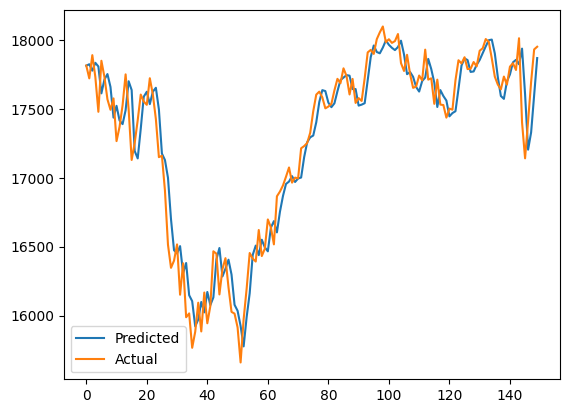

In [90]:
model_predict(150, X_valid, model_6, scaler, min(history_6.history["val_mean_squared_error"]), "Fine Tuned LSTM w/o Sentiment")

# Evaluate the Results

We see that `model_5` or the 'Fine Tuned LSTM + More Features' has beats the baseline naive model since its MASE < 1. Further clearing our doubts, we see that sentiment does have a role in increasing prediction accuracy. Though it isn't as significant as it may seem, it is still an external factor that may be regarded as an indicator of stock price fluctuations.

In [91]:
get_history()

,MASE,MSE,RMSE
Base LSTM,1.770422,13489.489148,116.144260
Deep(er) LSTM with Fine Tuning,1.398317,13481.819587,116.111238
Fine Tuned Base LSTM,1.121368,13474.071392,116.077868
Fine Tuned LSTM + Extra Features,1.008023,13474.394369,116.079259
Fine Tuned LSTM + More Features,1.107910,13497.449799,116.178526
Fine Tuned LSTM w/o Sentiment,1.009569,13495.651184,116.170785


To illustrate this better, we can plot the bar graphs of each model and its respective error metrics.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Base LSTM'),
  Text(1, 0, 'Deep(er) LSTM with Fine Tuning'),
  Text(2, 0, 'Fine Tuned Base LSTM'),
  Text(3, 0, 'Fine Tuned LSTM + Extra Features'),
  Text(4, 0, 'Fine Tuned LSTM + More Features'),
  Text(5, 0, 'Fine Tuned LSTM w/o Sentiment')])

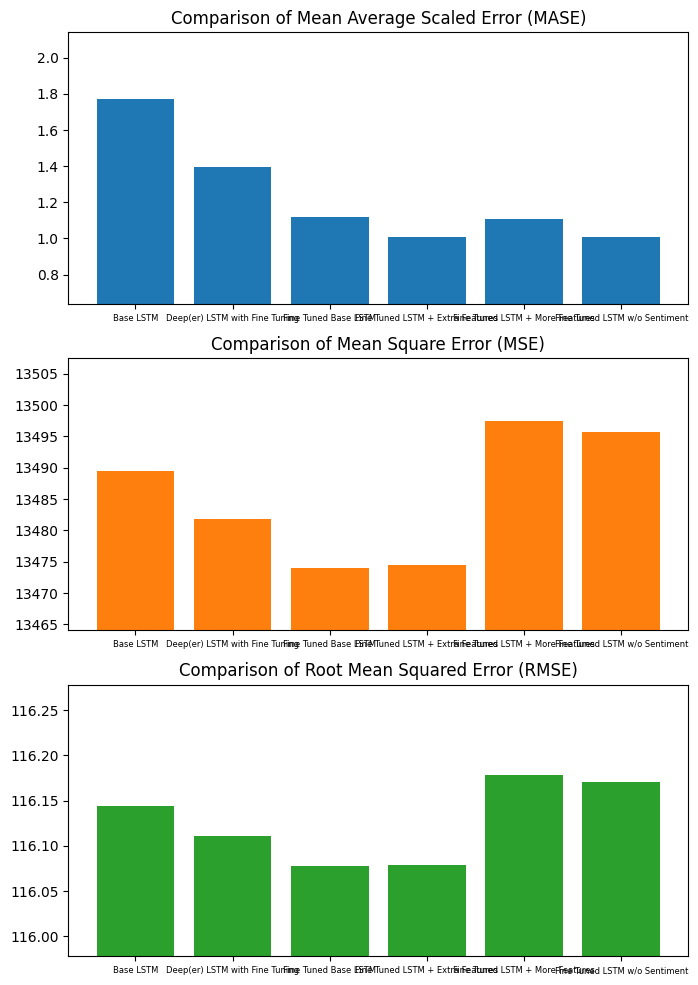

In [92]:
X_axis = np.arange(len(model_history))
mase = [err['MASE'] for err in model_history]
mse = [err['MSE'] for err in model_history]
rmse = [err['RMSE'] for err in model_history]

plt.figure(figsize=(8, 12))
plt.subplot(3,1,1)
plt.title("Comparison of Mean Average Scaled Error (MASE)")
plt.bar(model_name, mase, color='tab:blue')
plt.ylim([min(mase) - 0.3*np.mean(mase), max(mase) + 0.3*np.mean(mase)])
plt.xticks(fontsize=6)

plt.subplot(3,1,2)
plt.title("Comparison of Mean Square Error (MSE)")
plt.bar(model_name, mse, color='tab:orange')
plt.ylim([min(mse) - 10, max(mse) + 10])
plt.xticks(fontsize=6)

plt.subplot(3,1,3)
plt.title("Comparison of Root Mean Squared Error (RMSE)")
plt.bar(model_name, rmse, color='tab:green')
plt.ylim([min(rmse) - 0.1, max(rmse) + 0.1])
plt.xticks(fontsize=6)